In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary


import matplotlib.pyplot as plt
import numpy as np
import os
import random

from sklearn.metrics import confusion_matrix
import seaborn as sns
import json

In [ ]:
# Random seed per riproducidibilità
seed = 42

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# Connessione a Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/dataset/dataset_food_classification" "/content/dataset_food_classification"

In [ ]:
from torchvision.models import ResNet50_Weights

# Creo delle trasformazioni per il validazione ed il test set
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Ridimensiona l'immagine a 224x224
    transforms.ToTensor(),          # Converte l'immagine in un tensore PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizza il tensore usando i valori standard di ImageNet
])

# Per il dataset di train aggiungo delle modifiche delle immagini per migliorare la diversità dei dati (data augmentation)
data_augment = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), # Applica rotazione casuale
    transforms.RandomHorizontalFlip(p=0.5), # Applica flip orizzontale casuale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from torchvision.datasets import ImageFolder

# Specifico il percorso della directory principale del dataset
base_dir = '/content/dataset_food_classification'

# Le immagini devono essere organizzate in sottocartelle per classe come richiesto dalla classe ImageFolder che inferisce automaticamente le etichette (labels) delle classi dai nomi delle sottocartelle. Creo i dataset utilizzando ImageFolder e applico le trasformazioni
trainset = ImageFolder(root=f'{base_dir}/train', transform=data_augment)
valset = ImageFolder(root=f'{base_dir}/val', transform=data_transforms)
testset = ImageFolder(root=f'{base_dir}/test',transform=data_transforms)

# Stampa il numero totale di immagini nel dataset
print(f"Numero totale di immagini nel dataset di train: {len(trainset)}")
print(f"Numero totale di immagini nel dataset di validation: {len(valset)}")
print(f"Numero totale di immagini nel dataset di test: {len(testset)}")
print("---------------------------------------------------------")

def distribuzione_classe(dataset):
  targets = np.array(dataset.targets)
  classes, counts = np.unique(targets, return_counts=True)
  print(f"Distribuzione classi: {counts}")

# Stampa le classi rilevate da ImageFolder ed il numero
print(f"Classi rilevate: {testset.classes}")
print("---------------------------------------------------------")
print(f"Numero classi train set: {len(trainset.classes)}")
distribuzione_classe(trainset)
print("---------------------------------------------------------")
print(f"Numero classi test set: {len(testset.classes)}")
distribuzione_classe(testset)
print("---------------------------------------------------------")
print(f"Numero classi val set: {len(valset.classes)}")
distribuzione_classe(valset)


Numero totale di immagini nel dataset di train: 8686
Numero totale di immagini nel dataset di validation: 2240
Numero totale di immagini nel dataset di test: 2800
---------------------------------------------------------
Classi rilevate: ['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'cheesecake', 'chicken_curry', 'ice_cream', 'omelette', 'sushi']
---------------------------------------------------------
Numero classi train set: 14
Distribuzione classi: [640 640 640 640 640 640 640 640 640 640 640 640 450 556]
---------------------------------------------------------
Numero classi test set: 14
Distribuzione classi: [200 200 200 200 200 200 200 200 200 200 200 200 200 200]
---------------------------------------------------------
Numero classi val set: 14
Distribuzione classi: [160 160 160 160 160 160 160 160 160 160 160 160 160 160]


In [ ]:
#stampo le dimensioni del tensore che rappresenta l'immagine 300 del trainset
trainset[300][0].shape

torch.Size([3, 224, 224])

In [ ]:
# Funzione per mostrare un'immagine con le trasformazioni applicate
def imshow_transformed(img_tensor, title=None):
    # Denormalizza l'immagine (inverte la normalizzazione)
    imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    imagenet_std = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img_tensor = img_tensor * imagenet_std + imagenet_mean

    #  limita i valori di un tensore input nell'intervallo [0, 1] dopo la denormalizzazione
    img_tensor = torch.clamp(img_tensor, 0, 1)

    npimg = img_tensor.numpy() # Converto l'immagine trasformata in un tensore in un array numpy
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Sposto i canali RGB alla fine per la visualizzazione con matplotlib (C, H, W) -> (H, W, C)
    plt.title(title)
    plt.axis('off')
    plt.show()

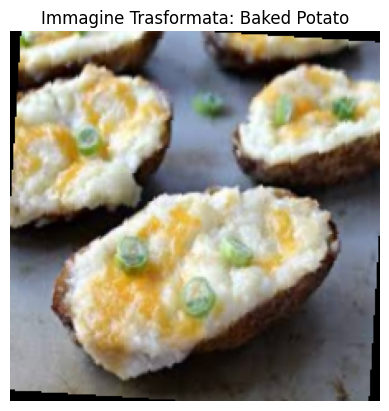

In [ ]:
# Seleziono la prima immagine del trainset (trainset[i] restituisce una tupla: (immagine_tensore, etichetta_indice))
image_tensor, label_index = trainset[0]

# Ottengo il nome della classe
label_name = trainset.classes[label_index]

# Mostro l'immagine con le trasformazioni applicate
imshow_transformed(image_tensor, title=f"Immagine Trasformata: {label_name}")

Come rete neurale pre-allenata, seleziono ResNet50

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).to(device)
summary(resnet, (3, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

Fine tunining parziale

ResNet50, pre-allenato su ImageNet, ha un layer finale (il layer fully connected) progettato per 1000 classi. Sostituisco questo layer finale con un nuovo layer fully connected che abbia un numero di unità pari al numero di classi del dataset, cioè 14 (determinato da testset.classes).

In [ ]:
# Numero di classi dal dataset. Mi serve per modificare l'output della classificazione (14 classi, non 1000 del modello ResNet50)
num_classes = len(testset.classes)
#Numero di features in input per l'ultimo strato (2048 per ResNet50)
num_features = resnet.fc.in_features

# Modifica l'ultimo strato completamente connesso del modello ResNet50 (resnet.fc). Da [2048,1000] a [2048,14]
resnet.fc = nn.Linear(num_features, num_classes)

# Sposto il modello sulla GPU
resnet.to(device)

# Stampo il riepilogo del modello modificato per verificare i cambiamenti
summary(resnet, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [ ]:
#Creo i DataLoader per i set di addestramento, validazione e test per poter gestire i dati in batch durante l'addestramento, la validazione e la valutazione finale.
from torch.utils.data import DataLoader

batch_size = 64

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Definisco funzione per ciclo di addestramento:

1-Iterare attraverso i batch di dati dal trainloader.

2- Per ogni batch, eseguire un forward pass con il modello per ottenere le predizioni.

3-Calcolare la funzione di perdita confrontando le predizioni con le etichette vere.

4-Eseguire una backward pass per calcolare i gradienti.

5-Aggiornare i pesi del modello utilizzando l'ottimizzatore.

6-Monitorare la perdita e l'accuratezza sul set di addestramento.

Stessa cosa per il ciclo di validazione ma senza il calcolo dei gradienti

In [ ]:
def train_model(model, trainloader, valloader, criterion, optimizer, epochs, patience, device, model_save_path):
  # Liste per memorizzare la perdita e l'accuratezza durante l'addestramento e la validazione
  train_loss_history = []
  train_acc_history = []
  val_loss_history = []
  val_acc_history = []

  # parametri per Early Stopping
  best_val_loss = float('inf') # Inizializza il valore della migliore loss di validazione a infinito
  epochs_no_improve = 0 # Contatore per le epoche senza miglioramento

  for epoch in range(epochs):  # ripeti il training per 100 epoche
      model.train() # Imposta il modello in modalità addestramento
      running_loss = 0.0 # inizializzo le variabili per tenere traccia della perdita totale (running_loss), del numero di predizioni corrette (correct_train) e del numero totale di immagini elaborate (total_train) per l'epoca corrente.
      correct_train = 0
      total_train = 0

      for i, data in enumerate(trainloader, 0):
          # dal Dataloader estrai un batch di immagini ed etichette (input, labels) e passalo su GPU
          inputs, labels = data
          inputs, labels = inputs.to(device), labels.to(device) #inputs=[batch_size, 2048, 1, 1], labels=[batch_size, 14]=[64,14]

          # azzera i gradienti accumulati dai passi precedenti
          optimizer.zero_grad()

          # forward pass passando le immagini di input attraverso il modello per ottenere le predizioni
          outputs = model(inputs) #[64,14]
          loss = criterion(outputs, labels)

          # backward pass per calcolare i gradienti della perdita rispetto a tutti i parametri addestrabili del modello e ottimizzazione per aggiornare i pesi
          loss.backward()
          optimizer.step()

          # aggiorna le statistiche per ogni batch
          running_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          total_train += labels.size(0)
          correct_train += (predicted == labels).sum().item()

      # calcolo delle metriche di epoca
      epoch_train_loss = running_loss / len(trainloader)
      epoch_train_acc = 100 * correct_train / total_train
      # memorizzazione: aggiunge la perdita e l'accuratezza dell'epoca corrente alle rispettive liste di storico
      train_loss_history.append(epoch_train_loss)
      train_acc_history.append(epoch_train_acc)

      print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')

      # Fase di validazione
      model.eval()  # Imposta il modello in modalità valutazione
      running_val_loss = 0.0
      correct_val = 0
      total_val = 0

      with torch.no_grad():  # disattiva il calcolo dei gradienti in fase di validazione
          for data in valloader:
              inputs, labels = data
              inputs, labels = inputs.to(device), labels.to(device)

              outputs = model(inputs)
              loss = criterion(outputs, labels)
              running_val_loss += loss.item()

              _, predicted = torch.max(outputs.data, 1)
              total_val += labels.size(0)
              correct_val += (predicted == labels).sum().item()

      epoch_val_loss = running_val_loss / len(valloader)
      epoch_val_acc = 100 * correct_val / total_val
      val_loss_history.append(epoch_val_loss)
      val_acc_history.append(epoch_val_acc)

      print(f'Epoch {epoch + 1}/{epochs}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

      # Early Stopping check
      if epoch_val_loss < best_val_loss:
          best_val_loss = epoch_val_loss
          epochs_no_improve = 0
          torch.save(model.state_dict(), model_save_path) #salvo il modello qui se questa è la migliore performance finora
          print(f"Salvo il miglior modello dentro {model_save_path}")
      else:
          epochs_no_improve += 1

      if epochs_no_improve == patience:
          print(f'Early stopping')
          break # esci dal ciclo di addestramento

  print('Addestramento completato')
  return train_loss_history, train_acc_history, val_loss_history, val_acc_history

Per il ciclo di addestramento di ResNet50 implemento una strategia di addestramento a due fasi:

1. Fase 1 (addestramento del solo layer di output): addestramento del solo layer di classificazione finale, con early stopping basato sulla loss di validazione.

2. Fase 2 (fine-tuning completo): Se la loss di validazione si stabilizza per un certo numero di epoche (patience) durante la Fase 1, sblocca tutti i layer del modello ResNet50 e continuare ad addestrare l'intera rete con un learning rate potenzialmente inferiore e un nuovo meccanismo di early stopping.


In [ ]:
print("\n--- Fase 1 (ResNet50) ---\n")

# congelo i pesi della rete pre-allenata
for param in resnet.parameters():
    param.requires_grad = False
# abilito il calcolo gradienti solo per i pesi del nuovo layer fc
for param in resnet.fc.parameters():
    param.requires_grad = True

criterion_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(resnet.parameters(), lr=0.001, weight_decay=1e-4) #sto passando solo i parametri del modello modificato per l'ottimizzazione. Aggiungo weight_decay per la regolarizzazione L2
epochs_1 = 10
patience_1 = 5 #epoche dopo le quali il training si ferma se non c'è miglioramento
model_save_path_1 = 'best_model_1.pth'

# Addestramento per la fase 1
train_loss_history_1, train_acc_history_1, val_loss_history_1, val_acc_history_1 = \
    train_model(resnet, trainloader, valloader, criterion_1, optimizer_1, epochs_1, patience_1, device, model_save_path_1)



--- Fase 1 (ResNet50)---

Epoch 1/10, Train Loss: 1.6001, Train Acc: 62.78%
Epoch 1/10, Val Loss: 1.0553, Val Acc: 76.16%
Saving best model to best_model_1.pth with Val Loss: 1.0553
Epoch 2/10, Train Loss: 0.9093, Train Acc: 78.06%
Epoch 2/10, Val Loss: 0.8179, Val Acc: 78.30%
Saving best model to best_model_1.pth with Val Loss: 0.8179
Epoch 3/10, Train Loss: 0.7306, Train Acc: 80.98%
Epoch 3/10, Val Loss: 0.7152, Val Acc: 80.54%
Saving best model to best_model_1.pth with Val Loss: 0.7152
Epoch 4/10, Train Loss: 0.6416, Train Acc: 82.96%
Epoch 4/10, Val Loss: 0.6531, Val Acc: 81.74%
Saving best model to best_model_1.pth with Val Loss: 0.6531
Epoch 5/10, Train Loss: 0.5732, Train Acc: 84.93%
Epoch 5/10, Val Loss: 0.6076, Val Acc: 82.50%
Saving best model to best_model_1.pth with Val Loss: 0.6076
Epoch 6/10, Train Loss: 0.5306, Train Acc: 85.34%
Epoch 6/10, Val Loss: 0.5904, Val Acc: 82.63%
Saving best model to best_model_1.pth with Val Loss: 0.5904
Epoch 7/10, Train Loss: 0.4874, Train

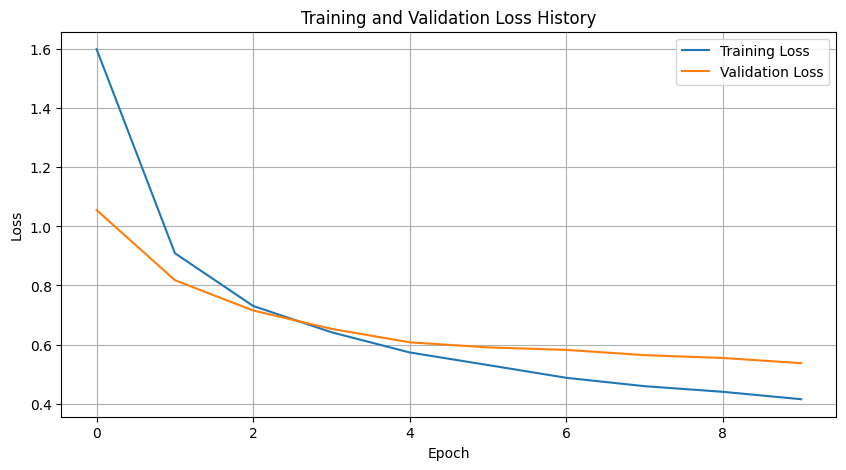

In [ ]:
# Stampo validation e training loss nelle epoche
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history_1, label='Training Loss')
plt.plot(val_loss_history_1, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss History')
plt.legend()
plt.grid(True)
plt.show()

Una volta completato l'addestramento, valuto le prestazioni finali del modello sul set di test (testloader):
*   Forward pass sui dati di test e predizione
*   Metriche di valutazione come accuratezza, precisione, ecc. e matrice di confusione.

In [ ]:
#Avevo già salvato i pesi del modello migliore trovato nella fase 1. Adesso creo un modello e ricarico questi pesi

# creo l'architettura identica
best_resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# modifico il layer finale
num_features = best_resnet.fc.in_features
best_resnet.fc = nn.Linear(num_features, 14)  # 14 classi

# carico i pesi migliori
best_resnet.load_state_dict(torch.load('best_model_1.pth'))

# passo il modello su GPU
best_resnet = best_resnet.to(device)

In [ ]:
# Fase di test 1
best_resnet.eval()  # Imposta il modello in modalità valutazione
#Vengono inizializzate le variabili per tenere traccia del numero di predizioni corrette (correct_test), del numero totale di immagini nel set di test (total_test). Vengono anche create due liste vuote, all_predicted e all_labels, per memorizzare tutte le predizioni del modello e le etichette vere rispettivamente (serviranno in seguito per calcolare metriche più dettagliate come la matrice di confusione).
correct_test = 0
total_test = 0
test_loss = 0.0
predizioni = [] #salvo predizioni ed etichette per poi generare la matrice di confusione
etichette = []

with torch.no_grad():  # Non calcolare i gradienti in fase di test
    for data in testloader:
        images, labels = data  #Estrae le immagini e le etichette dal batch.
        images, labels = images.to(device), labels.to(device)

        #forward pass
        outputs = best_resnet(images)

        #calcola la loss
        loss = criterion_1(outputs, labels)
        test_loss += loss.item()

        #Trova l'indice della classe con la probabilità più alta per ogni immagine nel batch. predicted conterrà le predizioni del modello per il batch corrente.
        _, predicted = torch.max(outputs.data, 1)

        #Aggiorna total_test con il numero di immagini nel batch corrente e correct_test con il numero di predizioni corrette in quel batch.
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        #Memorizzazione delle predizioni e etichette: aggiunge le predizioni e le etichette vere del batch corrente alle liste predizioni[] ed etichette[]. .cpu().numpy() converte i tensori PyTorch in array NumPy sulla CPU per poterli estendere alle liste Python create sopra
        predizioni.extend(predicted.cpu().numpy())
        etichette.extend(labels.cpu().numpy())

#Calcolo dell'accuratezza finale: numero totale di predizioni corrette (correct_test) diviso per il numero totale di immagini nel set di test (total_test)
test_acc = 100 * correct_test / total_test
print(f'Accuratezza sul set di test: {test_acc:.2f}%')

Accuratezza sul set di test: 83.04%


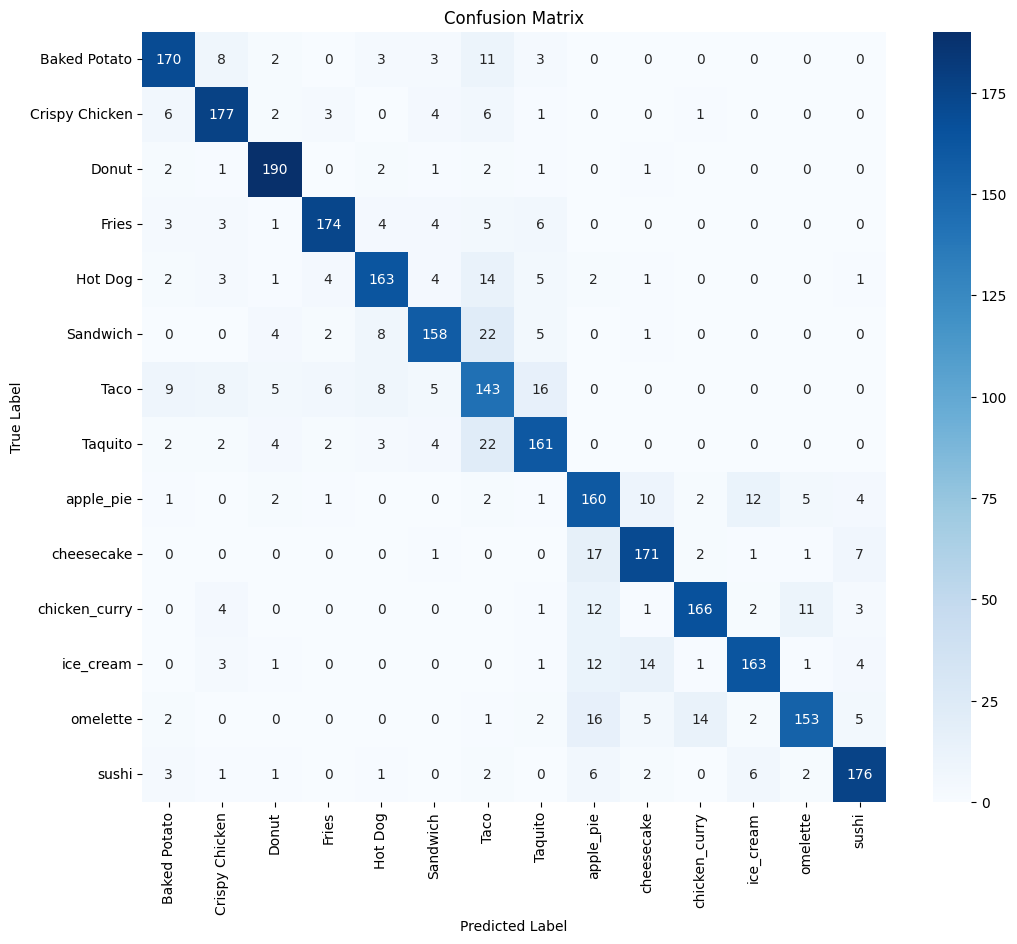

In [ ]:
# Genera la matrice di confusione
cm = confusion_matrix(etichette, predizioni)

# Visualizza la matrice di confusione
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=testset.classes, yticklabels=testset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Metriche di valutazione complete (precision, recall, F1-score e accuratezza per classe) per il modello ResNet50, sia sul set di addestramento che sul set di test, e visualizzare i risultati.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model_metrics(model, dataloader, device, class_names, dataset_name):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- Metriche di valutazione per il {dataset_name} sulle varie classi ---")
    # Calculate and print precision, recall, F1-score for each class
    print(classification_report(all_labels, all_predictions, target_names=class_names, zero_division=0))

    # Calculate and print overall accuracy
    overall_accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")


In [ ]:
evaluate_model_metrics(best_resnet, trainloader, device, testset.classes, 'train set')


--- Metriche di valutazione per il train set sulle varie classi ---
                precision    recall  f1-score   support

  Baked Potato       0.91      0.89      0.90       640
Crispy Chicken       0.88      0.93      0.90       640
         Donut       0.98      0.96      0.97       640
         Fries       0.95      0.91      0.93       640
       Hot Dog       0.95      0.89      0.92       640
      Sandwich       0.91      0.88      0.89       640
          Taco       0.78      0.86      0.82       640
       Taquito       0.85      0.86      0.86       640
     apple_pie       0.83      0.90      0.86       640
    cheesecake       0.89      0.91      0.90       640
 chicken_curry       0.96      0.93      0.94       640
     ice_cream       0.95      0.88      0.91       640
      omelette       0.91      0.88      0.90       450
         sushi       0.91      0.94      0.92       556

      accuracy                           0.90      8686
     macro avg       0.90      0.

In [ ]:
evaluate_model_metrics(best_resnet, testloader, device, testset.classes, 'test set')


--- Metriche di valutazione per il test set sulle varie classi ---
                precision    recall  f1-score   support

  Baked Potato       0.85      0.85      0.85       200
Crispy Chicken       0.84      0.89      0.86       200
         Donut       0.89      0.95      0.92       200
         Fries       0.91      0.87      0.89       200
       Hot Dog       0.85      0.81      0.83       200
      Sandwich       0.86      0.79      0.82       200
          Taco       0.62      0.71      0.67       200
       Taquito       0.79      0.81      0.80       200
     apple_pie       0.71      0.80      0.75       200
    cheesecake       0.83      0.85      0.84       200
 chicken_curry       0.89      0.83      0.86       200
     ice_cream       0.88      0.81      0.84       200
      omelette       0.88      0.77      0.82       200
         sushi       0.88      0.88      0.88       200

      accuracy                           0.83      2800
     macro avg       0.83      0.8

Fase 2: Fine-tuning completo di ResNet50, sbloccando tutti i layer del modello e continuando ad addestrare l'intera rete con un learning rate inferiore. Questo permetterà al modello di adattarsi meglio alle caratteristiche specifiche del dataset.

In [ ]:
print("\n--- Fase 2 (ResNet50) ---\n")

# Unfreeze di tutti i layer del modello best_resnet
for param in best_resnet.parameters():
    param.requires_grad = True

criterion_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(best_resnet.parameters(), lr=0.00001, weight_decay=1e-4)
epochs_2 = 15
patience_2 = 5
model_save_path_2 = 'best_model_2.pth'

# Addestramento per la fase 2
train_loss_history_2, train_acc_history_2, val_loss_history_2, val_acc_history_2 = \
    train_model(best_resnet, trainloader, valloader, criterion_2, optimizer_2, epochs_2, patience_2, device, model_save_path_2)


--- Fase 2 (ResNet50) ---

Epoch 1/15, Train Loss: 0.3768, Train Acc: 89.96%
Epoch 1/15, Val Loss: 0.5370, Val Acc: 83.48%
Saving best model to best_model_2.pth with Val Loss: 0.5370
Epoch 2/15, Train Loss: 0.3742, Train Acc: 89.72%
Epoch 2/15, Val Loss: 0.5370, Val Acc: 83.48%
Epoch 3/15, Train Loss: 0.3751, Train Acc: 90.01%
Epoch 3/15, Val Loss: 0.5370, Val Acc: 83.48%
Epoch 4/15, Train Loss: 0.3751, Train Acc: 89.55%
Epoch 4/15, Val Loss: 0.5370, Val Acc: 83.48%
Epoch 5/15, Train Loss: 0.3768, Train Acc: 89.89%
Epoch 5/15, Val Loss: 0.5370, Val Acc: 83.48%
Epoch 6/15, Train Loss: 0.3747, Train Acc: 90.02%
Epoch 6/15, Val Loss: 0.5370, Val Acc: 83.48%
Early stopping
Addestramento completato


Nonostante lo sblocco di tutti i layer e l'uso di un learning rate inferiore, il modello non è riuscito a migliorare la Validation Loss. L'early stopping si è attivato rapidamente perché la Validation Loss e l'Accuracy sono rimaste invariate (0.5370 e 83.48%) rispetto al miglior risultato della Fase 1

In [ ]:
# ricreo l'architettura identica
best_resnet_2 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# modifico il layer finale
num_features = best_resnet_2.fc.in_features
best_resnet_2.fc = nn.Linear(num_features, 14)

# carico i pesi migliori
best_resnet_2.load_state_dict(torch.load('best_model_2.pth'))

# passo il modello su GPU
best_resnet_2 = best_resnet_2.to(device)

In [ ]:
# Fase di test 2
best_resnet_2.eval()
correct_test2 = 0
total_test2 = 0
test_loss2 = 0.0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs2 = best_resnet_2(images)

        loss2 = criterion_2(outputs2, labels)
        test_loss2 += loss2.item()

        _, predicted2 = torch.max(outputs2.data, 1)

        total_test2 += labels.size(0)
        correct_test2 += (predicted2 == labels).sum().item()

test_acc2 = 100 * correct_test2 / total_test2
print(f'Accuratezza sul set di test: {test_acc2:.2f}%')

Accuratezza sul set di test: 83.04%


In [ ]:
evaluate_model_metrics(best_resnet_2, trainloader, device, testset.classes, 'train set')


--- Metriche di valutazione per il train set sulle varie classi ---
                precision    recall  f1-score   support

  Baked Potato       0.92      0.89      0.90       640
Crispy Chicken       0.88      0.94      0.91       640
         Donut       0.97      0.96      0.96       640
         Fries       0.94      0.91      0.93       640
       Hot Dog       0.93      0.88      0.90       640
      Sandwich       0.90      0.88      0.89       640
          Taco       0.80      0.86      0.83       640
       Taquito       0.85      0.87      0.86       640
     apple_pie       0.81      0.90      0.85       640
    cheesecake       0.90      0.91      0.90       640
 chicken_curry       0.95      0.92      0.93       640
     ice_cream       0.96      0.88      0.92       640
      omelette       0.91      0.86      0.89       450
         sushi       0.90      0.94      0.92       556

      accuracy                           0.90      8686
     macro avg       0.90      0.

In [ ]:
evaluate_model_metrics(best_resnet_2, testloader, device, testset.classes, 'test set')

Carico un modello EfficientNetV2 pre-addestrato, modifico il layer di classificazione finale per il numero specifico di classi (14) e applico la stessa strategia di addestramento a due fasi utilizzata per ResNet50.


In [ ]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

efficientnet = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1).to(device)
summary(efficientnet, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         [-1, 24, 112, 112]               0
           Conv2d-14           [-1, 96,

In [ ]:
# Numero di classi dal dataset
num_classes = len(testset.classes)
# Numero di features in input per l'ultimo strato fc di EfficientNetV2
num_features = efficientnet.classifier[1].in_features

# Modifica l'ultimo strato completamente connesso del modello EfficientNetV2
efficientnet.classifier[1] = nn.Linear(num_features, num_classes)

# Sposto il modello sulla GPU
efficientnet.to(device)

# Stampo il riepilogo del modello modificato per verificare i cambiamenti
summary(efficientnet, (3, 224, 224))


Summary of EfficientNetV2 after modification:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         [-1, 24, 112, 112]         

In [ ]:
print("\n--- Fase 1 (EfficientNetV2) ---\n")

# congelo i pesi della rete pre-allenata
for param in efficientnet.parameters():
    param.requires_grad = False
# abilito il calcolo gradienti solo per i pesi del nuovo layer classifier[1]
for param in efficientnet.classifier[1].parameters():
    param.requires_grad = True

criterion_eff = nn.CrossEntropyLoss()
optimizer_eff = torch.optim.Adam(efficientnet.classifier[1].parameters(), lr=0.001, weight_decay=1e-4)
epochs_eff = 10
patience_eff = 5 #epoche dopo le quali il training si ferma se non c'è miglioramento
model_save_path_eff = 'best_efficientnet_model_1.pth'

# Addestramento
train_loss_history_eff, train_acc_history_eff, val_loss_history_eff, val_acc_history_1_eff = \
    train_model(efficientnet, trainloader, valloader, criterion_eff, optimizer_eff, epochs_eff, patience_eff, device, model_save_path_eff)


--- Fase 1 (EfficientNetV2) ---

Epoch 1/15, Train Loss: 2.6484, Train Acc: 6.97%
Epoch 1/15, Val Loss: 2.6400, Val Acc: 8.66%
Saving best model to best_efficientnet_model_1.pth with Val Loss: 2.6400
Epoch 2/15, Train Loss: 2.6485, Train Acc: 6.77%
Epoch 2/15, Val Loss: 2.6400, Val Acc: 8.66%
Epoch 3/15, Train Loss: 2.6485, Train Acc: 6.70%
Epoch 3/15, Val Loss: 2.6400, Val Acc: 8.66%
Epoch 4/15, Train Loss: 2.6486, Train Acc: 6.95%
Epoch 4/15, Val Loss: 2.6400, Val Acc: 8.66%
Epoch 5/15, Train Loss: 2.6487, Train Acc: 7.24%
Epoch 5/15, Val Loss: 2.6400, Val Acc: 8.66%
Epoch 6/15, Train Loss: 2.6489, Train Acc: 7.13%
Epoch 6/15, Val Loss: 2.6400, Val Acc: 8.66%
Early stopping
Addestramento completato



Applico la funzione evaluate_model_metrics al modello EfficientNetV2 per calcolare e visualizzare metriche dettagliate (precision, recall, F1-score e accuratezza per classe) sia sul set di addestramento che sul set di test.


In [ ]:
evaluate_model_metrics(efficientnet, trainloader, device, testset.classes, 'train set')


--- Metriche di valutazione per il train set sulle varie classi ---
                precision    recall  f1-score   support

  Baked Potato       0.06      0.01      0.02       640
Crispy Chicken       0.07      0.01      0.01       640
         Donut       0.06      0.20      0.09       640
         Fries       0.10      0.01      0.02       640
       Hot Dog       0.00      0.00      0.00       640
      Sandwich       0.06      0.03      0.04       640
          Taco       0.13      0.19      0.16       640
       Taquito       0.10      0.11      0.10       640
     apple_pie       0.05      0.05      0.05       640
    cheesecake       0.02      0.07      0.03       640
 chicken_curry       0.37      0.18      0.24       640
     ice_cream       0.12      0.04      0.05       640
      omelette       0.02      0.01      0.01       450
         sushi       0.05      0.08      0.06       556

      accuracy                           0.07      8686
     macro avg       0.09      0.

In [ ]:
evaluate_model_metrics(efficientnet, testloader, device, testset.classes, 'test set')


--- Metriche di valutazione per il test set sulle varie classi ---
                precision    recall  f1-score   support

  Baked Potato       0.08      0.02      0.03       200
Crispy Chicken       0.00      0.00      0.00       200
         Donut       0.05      0.17      0.08       200
         Fries       0.12      0.02      0.03       200
       Hot Dog       0.00      0.00      0.00       200
      Sandwich       0.03      0.02      0.02       200
          Taco       0.12      0.20      0.15       200
       Taquito       0.10      0.12      0.11       200
     apple_pie       0.02      0.01      0.02       200
    cheesecake       0.03      0.10      0.05       200
 chicken_curry       0.35      0.26      0.30       200
     ice_cream       0.16      0.04      0.06       200
      omelette       0.07      0.01      0.02       200
         sushi       0.08      0.09      0.08       200

      accuracy                           0.08      2800
     macro avg       0.09      0.0

Il modello EfficientNetV2 ha mostrato metriche di performance estremamente basse durante la Fase 1 di addestramento. Questo risultato è significativamente inferiore rispetto a ResNet50 e suggerisce che il modello non ha appreso efficacemente come classificare le immagini del dataset con il solo addestramento del layer finale.

Diverse ragioni possono spiegare queste basse prestazioni:

1.  **(Discrepanza di Dominio)**: Sebbene EfficientNetV2 sia pre-addestrato su ImageNet, il dataset "food classification" potrebbe avere caratteristiche visive molto diverse da quelle su cui il modello è stato originariamente addestrato. Le feature estratti dai layer convoluzionali congelati potrebbero non essere sufficientemente rappresentative per le classi specifiche del cibo, rendendo difficile per il layer di classificazione finale imparare una mappatura efficace.

2.  **Efficacia Limitata del fine-tuning del solo strato finale**: EfficientNetV2 è un modello molto profondo e complesso. Congelare quasi tutti i layer e addestrare solo l'ultimo strato lineare (il classificatore) può essere un approccio troppo restrittivo. Il modello potrebbe aver bisogno di aggiornare i pesi anche nei layer più profondi (estrattori di feature) per adattarsi al nuovo compito.

3.  **Impatto del Learning Rate**: Un learning rate di 0.001 potrebbe essere alto per l'addestramento del solo layer finale di EfficientNetV2. Se i pesi del layer sono stati inizializzati casualmente (come avviene per un nuovo layer) e il resto del modello è congelato, un learning rate troppo alto potrebbe aver causato oscillazioni o una convergenza rapida a un minimo subottimale, senza permettere al modello di stabilizzarsi.

In sintesi, la strategia di addestramento della Fase 1 (addestramento del solo layer di classificazione) non è stata sufficiente per consentire a EfficientNetV2 di adattarsi efficacemente al dataset di classificazione del cibo. Questo contrasta con ResNet50, che nella stessa fase ha mostrato prestazioni notevolmente migliori, suggerendo una maggiore adattabilità dei suoi feature pre-addestrati o una minore sensibilità del suo layer finale a queste condizioni iniziali.

### Analisi finale

#### ResNet50:
Il modello ResNet50 ha dimostrato prestazioni notevoli fin dalla Fase 1 del fine-tuning, dove è stato addestrato solo il layer di classificazione finale, mantenendo congelati i layer convoluzionali pre-addestrati su ImageNet.

Nella Fase 2, dove tutti i layer del modello sono stati sbloccati per un fine-tuning con un learning rate inferiore, il modello non ha mostrato ulteriori miglioramenti significativi. L'early stopping è stato attivato dopo poche epoche poiché la Validation Loss è rimasta invariata rispetto al miglior risultato della Fase 1. Questo suggerisce che le feature estratte dai layer convoluzionali pre-addestrati erano già molto pertinenti al task di classificazione del cibo, e l'addestramento del solo layer finale è stato sufficiente per adattare il modello al nuovo dataset.

#### EfficientNetV2:
In contrasto, il modello EfficientNetV2 ha mostrato prestazioni estremamente basse durante la Fase 1 di addestramento, indicando difficoltà nell'adattamento al dataset di classificazione del cibo con la stessa strategia di fine-tuning.


### Intuizioni

*   **Adattabilità dei Modelli Pre-addestrati:** La scelta del modello pre-addestrato è cruciale. Alcune architetture (come ResNet50) possono avere feature più generalizzabili o essere più robuste a semplici strategie di fine-tuning rispetto ad altre (come EfficientNetV2) per specifici domini di dati.
*   **Fine-tuning progressivo:** La strategia di fine-tuning a due fasi (prima il layer finale, poi l'intera rete) è valida, ma la sua efficacia dipende dal modello e dal dataset. Per ResNet50, la Fase 1 si è dimostrata estremamente efficace, tanto che la Fase 2 non ha portato a miglioramenti. Per EfficientNetV2, la Fase 1 è stata fallimentare, indicando la necessità di un approccio più elaborato fin dall'inizio (es. sblocco parziale dei layer, ricerca di un learning rate più adatto, architettura della testa più complessa).
*   **Sensibilità degli iperparametri:** I modelli più complessi e moderni, pur avendo un grande potenziale, possono essere più sensibili alla scelta degli iperparametri (come il learning rate) e alle strategie di ottimizzazione, soprattutto nelle fasi iniziali del fine-tuning.